In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def getkb(X,Y):
    k=(np.average(Y*X)-np.average(Y)*np.average(X))/(np.average(X*X)-np.average(X)**2)
    b=np.average(Y)-k*np.average(X)
    sigk=np.sqrt(np.abs((np.average(Y*Y)-np.average(Y)*np.average(Y))/(np.average(X*X)-np.average(X)**2) - k*k))/np.sqrt(X.shape[0])
    sigb=sigk*np.sqrt(np.average(X*X)-np.average(X)**2)
    return np.array([k,b,np.abs(sigk/k),np.abs(sigb/b)])

In [17]:
dt=pd.read_excel("data.xlsx",sheet_name=0)
dt

,m,b,w,rb,rw,mw
0,10,12.0,19.0,281.4875,274.4875,9.5
1,9,24.0,30.0,269.4875,263.4875,8.5
2,8,38.0,48.0,255.4875,245.4875,7.5
3,7,55.0,62.0,238.4875,231.4875,6.5
4,6,72.0,80.5,221.4875,212.9875,5.5
5,5,90.5,99.5,202.9875,193.9875,4.5
6,4,110.0,121.0,183.4875,172.4875,3.5
7,3,134.5,149.0,158.9875,144.4875,2.5
8,2,163.5,185.0,129.9875,108.4875,1.5
9,1,207.0,230.5,86.4875,62.9875,0.5


In [18]:
getkb(dt.m,dt.rb**2*np.sign(dt.m))

array([8.07373392e+03, 8.14050000e+01, 5.23915518e-03, 3.22414807e+00])

In [19]:
getkb(dt.mw,dt.rw**2*np.sign(dt.mw))

array([8.07971419e+03, 1.46585625e+02, 4.32579834e-03, 1.37488606e+00])

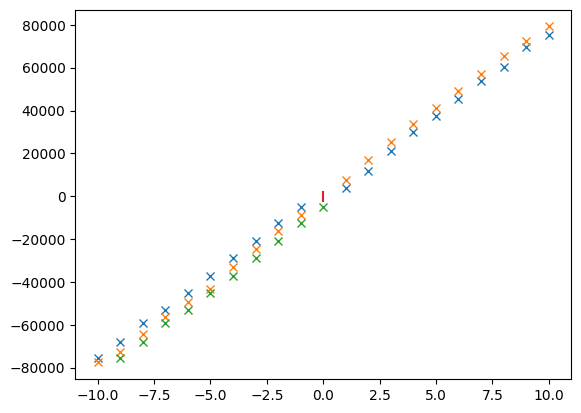

In [14]:
plt.errorbar(dt.m,dt.rw**2*np.sign(dt.m),fmt="x")
plt.errorbar(dt.m,dt.rb**2*np.sign(dt.m),fmt="x")
plt.plot([0,0],[44.48**2,-(48.51**2)])

In [36]:
a1,b1,sa1,sb1=getkb(np.abs(dt.m),dt.rw**2)
a2,b2,sa2,sb2=getkb(np.abs(dt.m),dt.rb**2)

In [37]:
a1,b1,sa1,sb1

(7926.476401515157,
 -2944.20692708336,
 0.00745521584919973,
 0.05764996355803444)

In [54]:
(7892+7926)/2

7909.0

In [55]:
7900e-12/(578e-9)

0.013667820069204152

In [38]:
a2,b2,sa2,sb2

(7892.292348484847,
 1270.0909895833393,
 0.010052998963191707,
 0.17942829948115863)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


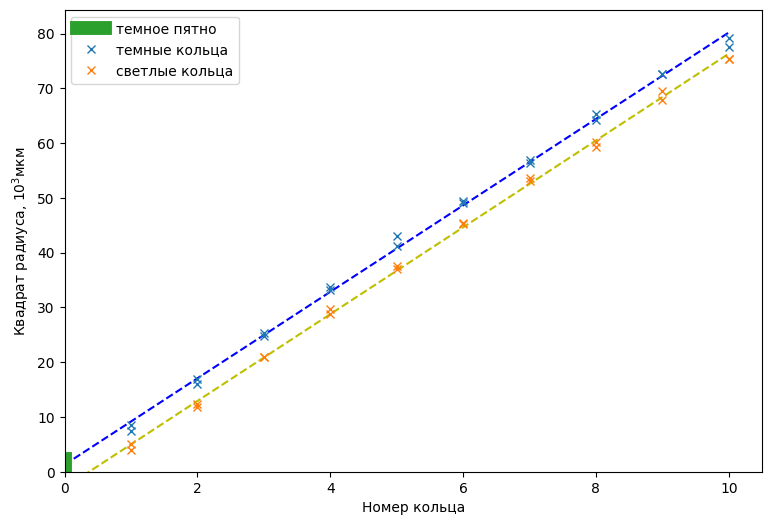

In [56]:
l=np.linspace(0,10,10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(np.abs(dt.m),dt.rb**2/1000,fmt="x",label="темные кольца")
ax.errorbar(np.abs(dt.m),dt.rw**2/1000,fmt="x",label="светлые кольца")
ax.plot(l,(l*a1+b1)/1000,'--y')
ax.plot(l,(l*a2+b2)/1000,'--b')
ax.plot([0,0],[0,(48.51**2)/1000], linewidth=10,label="темное пятно")
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
ax.set_ylabel('Квадрат радиуса, $10^3$мкм')
ax.set_xlabel('Номер кольца')
ax.legend()
plt.savefig("newton.eps")